# Audio Sentiment Prediction

Audio emotion models peaked at ~0.35 weighted F1 on the 8-class task — fine-grained emotion labels are difficult to distinguish from prosody alone.  
This notebook asks a simpler question: **can audio features reliably predict 3-class *sentiment* (negative / neutral / positive)?**

Motivation: sentiment is a coarser, valence-based grouping:
- **negative** ← anger, sadness, disgust, fear, surprise_negative
- **neutral**  ← neutral
- **positive** ← joy, surprise_positive

The same openSMILE feature sets (eGeMAPSv02 / IS10 / emobase) are reused — only the target changes.

| Model | Feature sets | Search | Trials |
|---|---|---|---|
| **LR** | egemaps, is10, emobase | Bayesian (Optuna) | 30 |
| **SVM** | egemaps, is10, emobase | Bayesian (Optuna) | 20 |
| **MLP** | egemaps, is10, emobase | Bayesian (Optuna) | 20 |

## Setup

In [1]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)

SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import (
    FEATURES_DIR, CSV_FILES, CHECKPOINTS_DIR, METRICS_DIR, PREDICTIONS_DIR,
    FEATURE_SETS, RANDOM_SEED
)
from audio.dataset import load_feature_dataframe

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

for d in (CHECKPOINTS_DIR, METRICS_DIR, PREDICTIONS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Sentiment mapping ────────────────────────────────────────────────────────
SENTIMENT_LABELS = ["negative", "neutral", "positive"]
SENT2IDX = {s: i for i, s in enumerate(SENTIMENT_LABELS)}
N_SENT   = len(SENTIMENT_LABELS)

print("Sentiment classes:", SENTIMENT_LABELS)
print("Feature sets:", list(FEATURE_SETS))

Sentiment classes: ['negative', 'neutral', 'positive']
Feature sets: ['egemaps', 'is10', 'emobase']


## Data Loading

In [2]:
def load_sentiment_arrays(
    split: str,
    feature_set: str,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Load audio feature array + 3-class sentiment labels for the given split.
    Joins the openSMILE parquet with the raw CSV on dialogue_id / utterance_id.
    """
    feat_df = load_feature_dataframe(split=split, feature_set=feature_set)

    raw_df = pd.read_csv(CSV_FILES[split])[["Dialogue_ID", "Utterance_ID", "Sentiment"]]

    merged = feat_df.merge(
        raw_df,
        left_on=["dialogue_id", "utterance_id"],
        right_on=["Dialogue_ID", "Utterance_ID"],
        how="left",
    )

    if merged["Sentiment"].isna().any():
        n_missing = int(merged["Sentiment"].isna().sum())
        print(f"[WARN] {n_missing} unmatched row(s) in {split}/{feature_set} — dropping.")
        merged = merged.dropna(subset=["Sentiment"]).reset_index(drop=True)

    id_cols = {"dialogue_id", "utterance_id", "label_idx", "Dialogue_ID", "Utterance_ID", "Sentiment"}
    feat_cols = [c for c in merged.columns if c not in id_cols]

    X = merged[feat_cols].values.astype(np.float32)
    y = merged["Sentiment"].map(SENT2IDX).values.astype(int)
    return X, y


def save_sentiment_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    tag: str,
    save_plots: bool = True,
) -> dict:
    wf1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mf1 = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true, y_pred, target_names=SENTIMENT_LABELS,
        output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    results = {
        "model":       tag,
        "weighted_f1": round(wf1, 4),
        "macro_f1":    round(mf1, 4),
        "accuracy":    round(acc, 4),
        "per_class":   {
            label: {
                "precision": round(report[label]["precision"], 4),
                "recall":    round(report[label]["recall"],    4),
                "f1":        round(report[label]["f1-score"],  4),
                "support":   int(report[label]["support"]),
            }
            for label in SENTIMENT_LABELS
        },
    }

    (METRICS_DIR / f"{tag}.json").write_text(json.dumps(results, indent=2))

    print(f"\n{'='*50}")
    print(f"Model: {tag}")
    print(f"  Weighted F1 : {wf1:.4f}")
    print(f"  Macro F1    : {mf1:.4f}")
    print(f"  Accuracy    : {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=SENTIMENT_LABELS, zero_division=0))

    if save_plots:
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS, ax=ax)
        ax.set_title(f"Confusion Matrix — {tag}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        plt.tight_layout()
        plt.savefig(METRICS_DIR.parent / "plots" / f"cm_{tag}.png", dpi=150)
        plt.show()

    return results


def load_sent_metrics(pattern: str) -> pd.DataFrame:
    rows = []
    for key in FEATURE_SETS:
        p = METRICS_DIR / pattern.format(key)
        if p.exists():
            m = json.loads(p.read_text())
            rows.append({"feature_set": key,
                         "weighted_f1": m["weighted_f1"],
                         "macro_f1":    m["macro_f1"],
                         "accuracy":    m["accuracy"]})
    return pd.DataFrame(rows).set_index("feature_set") if rows else pd.DataFrame()


print("Functions defined.")

Functions defined.


### Class Distribution

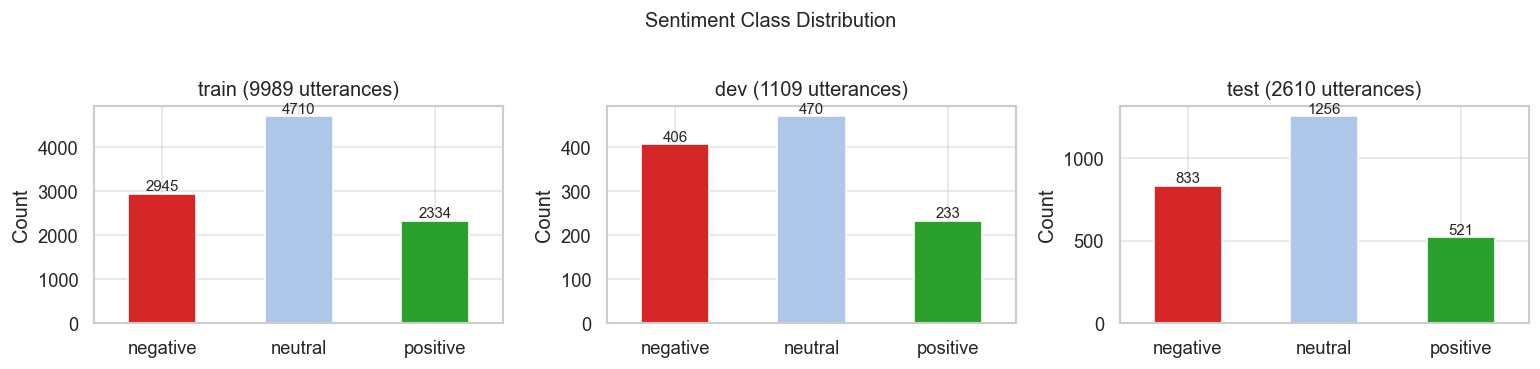

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

for ax, split in zip(axes, ["train", "dev", "test"]):
    raw = pd.read_csv(CSV_FILES[split])
    counts = raw["Sentiment"].value_counts().reindex(SENTIMENT_LABELS)
    counts.plot(kind="bar", ax=ax, color=["#d62728", "#aec7e8", "#2ca02c"], edgecolor="white")
    ax.set_title(f"{split} ({len(raw)} utterances)")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    for bar in ax.patches:
        ax.annotate(f"{int(bar.get_height())}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.suptitle("Sentiment Class Distribution", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(METRICS_DIR.parent / "plots" / "sentiment_class_dist.png", bbox_inches="tight")
plt.show()

---
## 1  Logistic Regression

Bayesian search (30 trials) over `C ∈ [1e-3, 10]`, `solver ∈ {lbfgs, saga}`, `max_iter ∈ [500, 3000]`.  
Objective: **dev macro F1** (same as emotion notebook).  
Class weights set to `balanced` throughout.


── LR | egemaps ─────────────────
Bayesian search (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWa

Best dev mF1: 0.4669  |  params: {'C': 3.475962581525656, 'solver': 'saga', 'max_iter': 500}


/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Model: audio_sent_lr_egemaps
  Weighted F1 : 0.4678
  Macro F1    : 0.4350
  Accuracy    : 0.4586
              precision    recall  f1-score   support

    negative       0.43      0.43      0.43       833
     neutral       0.61      0.51      0.55      1256
    positive       0.28      0.38      0.32       521

    accuracy                           0.46      2610
   macro avg       0.44      0.44      0.43      2610
weighted avg       0.48      0.46      0.47      2610



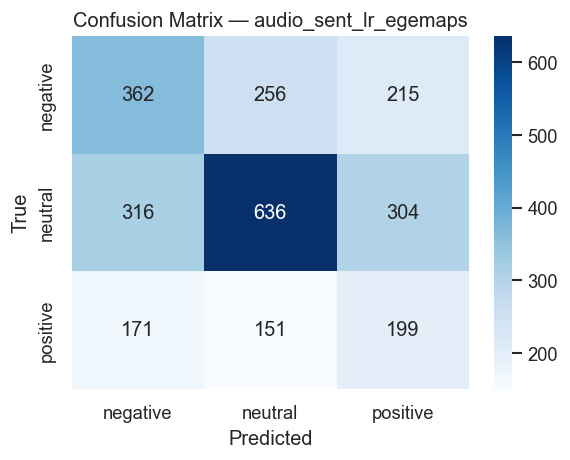


── LR | is10 ─────────────────
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
[WARN] Dropped 2 row(s) with NaN values from dev_is10.parquet (dev/is10).
Bayesian search (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-06-03 00:01:42,395] Trial 0 failed with parameters: {'C': 8.76300267341391, 'solver': 'lbfgs', 'max_iter': 1000} because of the following error: KeyboardInterrupt().
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
  File "/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
  File "/Users/priyanthvijayasures/Documents/000_Schule/Bachelor Data Science/6. Semester/NLP_Projekte/NLP_P3/.venv/lib/python3.10/site-packages/joblib/parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, ar

KeyboardInterrupt: 

In [15]:
N_TRIALS_LR = 30

def train_lr_sentiment(feature_set: str) -> dict:
    tag = f"audio_sent_lr_{feature_set}"
    print(f"\n── LR | {feature_set} ─────────────────")

    X_tr, y_tr = load_sentiment_arrays("train", feature_set)
    X_dv, y_dv = load_sentiment_arrays("dev",   feature_set)
    X_te, y_te = load_sentiment_arrays("test",  feature_set)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_dv = scaler.transform(X_dv)
    X_te = scaler.transform(X_te)

    with open(CHECKPOINTS_DIR / f"{tag}_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    def objective(trial):
        C        = trial.suggest_float("C",        1e-3, 10.0, log=True)
        solver   = trial.suggest_categorical("solver", ["lbfgs", "saga"])
        max_iter = trial.suggest_int("max_iter", 500, 3000, step=500)
        clf = LogisticRegression(C=C, solver=solver, max_iter=max_iter,
                                 class_weight="balanced", random_state=RANDOM_SEED, n_jobs=2)
        clf.fit(X_tr, y_tr)
        return f1_score(y_dv, clf.predict(X_dv), average="weighted", zero_division=0)

    print(f"Bayesian search ({N_TRIALS_LR} trials)...")
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS_LR, n_jobs=4, show_progress_bar=True)

    best = study.best_params
    print(f"Best dev mF1: {study.best_value:.4f}  |  params: {best}")

    clf = LogisticRegression(C=best["C"], solver=best["solver"], max_iter=best["max_iter"],
                             class_weight="balanced", random_state=RANDOM_SEED, n_jobs=2)
    clf.fit(X_tr, y_tr)

    with open(CHECKPOINTS_DIR / f"{tag}_model.pkl", "wb") as f:
        pickle.dump(clf, f)

    y_pred = clf.predict(X_te)
    results = save_sentiment_metrics(y_te, y_pred, tag)

    proba = clf.predict_proba(X_te)
    softmax = np.zeros((len(y_te), N_SENT), dtype=np.float32)
    for col_i, cls_i in enumerate(clf.classes_):
        softmax[:, cls_i] = proba[:, col_i]
    np.save(PREDICTIONS_DIR / f"{tag}_softmax_test.npy", softmax)

    return results


lr_results_raw = {}
for fs in FEATURE_SETS:
    lr_results_raw[fs] = train_lr_sentiment(fs)

In [5]:
lr_results = load_sent_metrics("audio_sent_lr_{}.json")
display(lr_results.style.highlight_max(axis=0, color="#d4f1c4").format("{:.4f}"))

,weighted_f1,macro_f1,accuracy
feature_set,,,
egemaps,0.4691,0.4363,0.4602
is10,0.4596,0.4333,0.4510
emobase,0.4637,0.4378,0.4544


---
## 2  SVM (LinearSVC + Platt calibration)

Bayesian search (20 trials) over `C`, `tol`, `max_iter`.  
Platt calibration (`cv='prefit'`) on the dev set — no calibration folds needed.


── SVM | egemaps ────────────────
Bayesian search (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1: 0.3949  |  params: {'C': 4.603953123429487, 'tol': 0.0012369059721488577, 'max_iter': 2500}

Model: audio_sent_svm_egemaps
  Weighted F1 : 0.4687
  Macro F1    : 0.3838
  Accuracy    : 0.5241
              precision    recall  f1-score   support

    negative       0.45      0.48      0.46       833
     neutral       0.57      0.76      0.65      1256
    positive       0.29      0.02      0.04       521

    accuracy                           0.52      2610
   macro avg       0.44      0.42      0.38      2610
weighted avg       0.48      0.52      0.47      2610



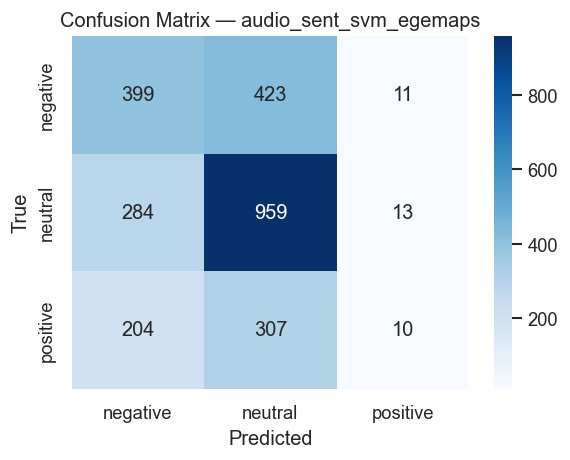


── SVM | is10 ────────────────
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
[WARN] Dropped 2 row(s) with NaN values from dev_is10.parquet (dev/is10).
Bayesian search (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1: 0.3882  |  params: {'C': 0.001021959444894088, 'tol': 0.008710410153014547, 'max_iter': 1000}

Model: audio_sent_svm_is10
  Weighted F1 : 0.4632
  Macro F1    : 0.3823
  Accuracy    : 0.5153
              precision    recall  f1-score   support

    negative       0.44      0.46      0.45       833
     neutral       0.56      0.75      0.64      1256
    positive       0.36      0.03      0.06       521

    accuracy                           0.52      2610
   macro avg       0.45      0.41      0.38      2610
weighted avg       0.48      0.52      0.46      2610



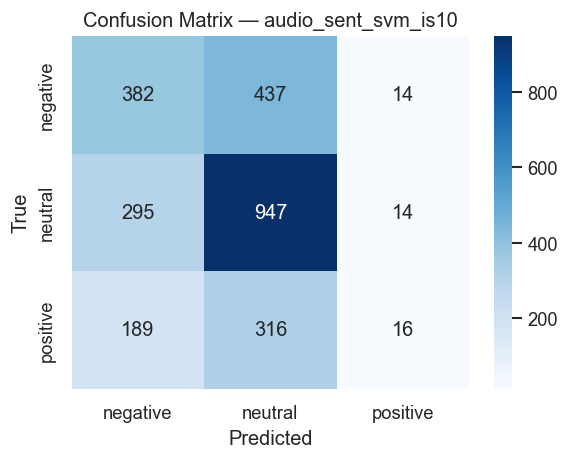


── SVM | emobase ────────────────
Bayesian search (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1: 0.3926  |  params: {'C': 0.0014998253420768252, 'tol': 0.000740378108534844, 'max_iter': 500}

Model: audio_sent_svm_emobase
  Weighted F1 : 0.4490
  Macro F1    : 0.3654
  Accuracy    : 0.5065
              precision    recall  f1-score   support

    negative       0.43      0.43      0.43       833
     neutral       0.55      0.76      0.64      1256
    positive       0.39      0.02      0.03       521

    accuracy                           0.51      2610
   macro avg       0.45      0.40      0.37      2610
weighted avg       0.48      0.51      0.45      2610



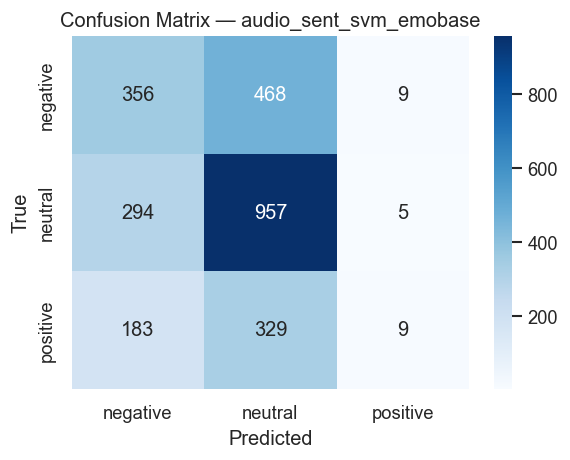

In [6]:
N_TRIALS_SVM = 20

def train_svm_sentiment(feature_set: str) -> dict:
    tag = f"audio_sent_svm_{feature_set}"
    print(f"\n── SVM | {feature_set} ────────────────")

    X_tr, y_tr = load_sentiment_arrays("train", feature_set)
    X_dv, y_dv = load_sentiment_arrays("dev",   feature_set)
    X_te, y_te = load_sentiment_arrays("test",  feature_set)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_dv = scaler.transform(X_dv)
    X_te = scaler.transform(X_te)

    with open(CHECKPOINTS_DIR / f"{tag}_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    def objective(trial):
        C        = trial.suggest_float("C",        1e-3, 10.0,  log=True)
        tol      = trial.suggest_float("tol",      1e-5, 1e-2,  log=True)
        max_iter = trial.suggest_int("max_iter", 500, 3000, step=500)
        svm = LinearSVC(C=C, tol=tol, max_iter=max_iter,
                        class_weight="balanced", random_state=RANDOM_SEED)
        svm.fit(X_tr, y_tr)
        cal = CalibratedClassifierCV(svm, cv="prefit")
        cal.fit(X_dv, y_dv)
        return f1_score(y_dv, cal.predict(X_dv), average="weighted", zero_division=0)

    print(f"Bayesian search ({N_TRIALS_SVM} trials)...")
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS_SVM, n_jobs=4, show_progress_bar=True)

    best = study.best_params
    print(f"Best dev mF1: {study.best_value:.4f}  |  params: {best}")

    svm = LinearSVC(C=best["C"], tol=best["tol"], max_iter=best["max_iter"],
                    class_weight="balanced", random_state=RANDOM_SEED)
    svm.fit(X_tr, y_tr)
    clf = CalibratedClassifierCV(svm, cv="prefit")
    clf.fit(X_dv, y_dv)

    with open(CHECKPOINTS_DIR / f"{tag}_model.pkl", "wb") as f:
        pickle.dump(clf, f)

    y_pred = clf.predict(X_te)
    results = save_sentiment_metrics(y_te, y_pred, tag)

    proba = clf.predict_proba(X_te)
    np.save(PREDICTIONS_DIR / f"{tag}_softmax_test.npy", proba.astype(np.float32))

    return results


svm_results_raw = {}
for fs in FEATURE_SETS:
    svm_results_raw[fs] = train_svm_sentiment(fs)

In [7]:
svm_results = load_sent_metrics("audio_sent_svm_{}.json")
display(svm_results.style.highlight_max(axis=0, color="#d4f1c4").format("{:.4f}"))

,weighted_f1,macro_f1,accuracy
feature_set,,,
egemaps,0.4687,0.3838,0.5241
is10,0.4632,0.3823,0.5153
emobase,0.4490,0.3654,0.5065


---
## 3  MLP

Bayesian search (20 trials) over architecture `[hidden_1, hidden_2]`, `dropout`, `lr`, `focal_gamma`.  
FocalLoss with balanced class weights. Early stopping (patience=10) on dev macro F1.  
Final training: max 100 epochs with ReduceLROnPlateau.

Device: cpu

── MLP | egemaps ────────────────
Bayesian search (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1: 0.4456  |  params: {'hidden_1': 128, 'hidden_2': 256, 'dropout': 0.34044600469728353, 'lr': 0.0015958573588141277, 'focal_gamma': 0.5514612357395061}
Final training (max 100 epochs, patience=10)...
Best final dev mF1: 0.4496

Model: audio_sent_mlp_egemaps
  Weighted F1 : 0.4714
  Macro F1    : 0.4344
  Accuracy    : 0.4659
              precision    recall  f1-score   support

    negative       0.42      0.40      0.41       833
     neutral       0.60      0.55      0.58      1256
    positive       0.28      0.36      0.32       521

    accuracy                           0.47      2610
   macro avg       0.43      0.44      0.43      2610
weighted avg       0.48      0.47      0.47      2610



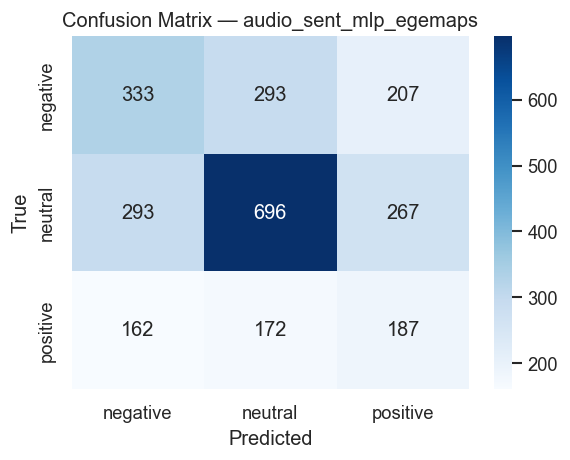


── MLP | is10 ────────────────
[WARN] Dropped 6 row(s) with NaN values from train_is10.parquet (train/is10).
[WARN] Dropped 2 row(s) with NaN values from dev_is10.parquet (dev/is10).
Bayesian search (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1: 0.4785  |  params: {'hidden_1': 256, 'hidden_2': 64, 'dropout': 0.3611719000163914, 'lr': 0.0001796305844938394, 'focal_gamma': 0.995765303326664}
Final training (max 100 epochs, patience=10)...
Best final dev mF1: 0.4641

Model: audio_sent_mlp_is10
  Weighted F1 : 0.4536
  Macro F1    : 0.4246
  Accuracy    : 0.4464
              precision    recall  f1-score   support

    negative       0.42      0.47      0.44       833
     neutral       0.58      0.47      0.52      1256
    positive       0.28      0.35      0.31       521

    accuracy                           0.45      2610
   macro avg       0.43      0.43      0.42      2610
weighted avg       0.47      0.45      0.45      2610



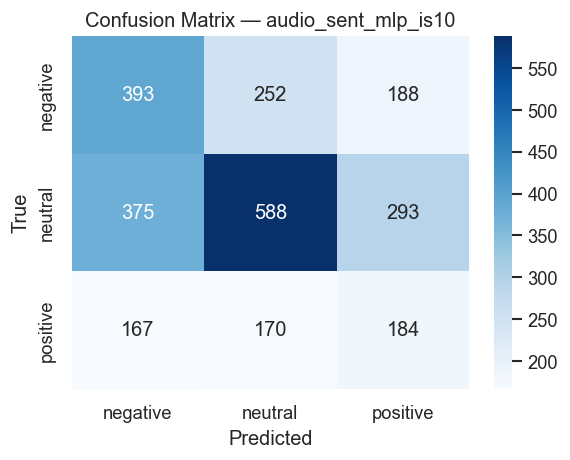


── MLP | emobase ────────────────
Bayesian search (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best dev mF1: 0.4595  |  params: {'hidden_1': 512, 'hidden_2': 128, 'dropout': 0.3478985205994819, 'lr': 0.00029264542309990257, 'focal_gamma': 1.6263209265728595}
Final training (max 100 epochs, patience=10)...
Best final dev mF1: 0.4632

Model: audio_sent_mlp_emobase
  Weighted F1 : 0.4752
  Macro F1    : 0.4438
  Accuracy    : 0.4678
              precision    recall  f1-score   support

    negative       0.43      0.44      0.44       833
     neutral       0.60      0.52      0.56      1256
    positive       0.30      0.39      0.34       521

    accuracy                           0.47      2610
   macro avg       0.44      0.45      0.44      2610
weighted avg       0.49      0.47      0.48      2610



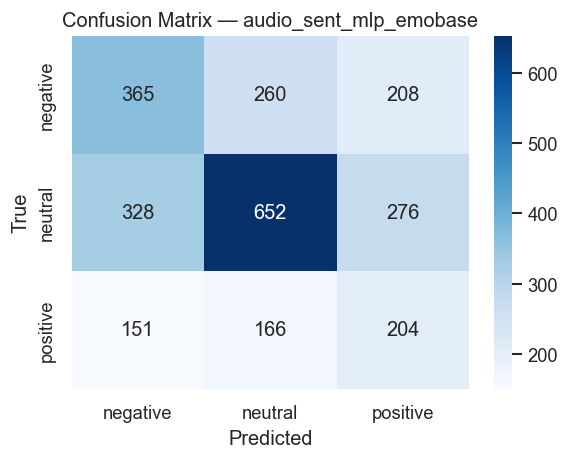

In [8]:
N_TRIALS_MLP = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, weight: torch.Tensor | None = None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_p = nn.functional.log_softmax(logits, dim=-1)
        p     = log_p.exp()
        ce    = nn.functional.nll_loss(log_p, targets, weight=self.weight, reduction="none")
        pt    = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        return ((1 - pt) ** self.gamma * ce).mean()


class SentMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_1: int, hidden_2: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.BatchNorm1d(hidden_1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.BatchNorm1d(hidden_2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_2, N_SENT),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def _make_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def _eval_mf1(model, loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(dim=1).cpu()
            all_pred.append(preds); all_true.append(yb)
    return f1_score(torch.cat(all_true), torch.cat(all_pred), average="weighted", zero_division=0)


def _train_mlp_run(X_tr, y_tr, X_dv, y_dv, h1, h2, drop, lr, gamma, max_epochs=100, patience=10):
    counts = np.bincount(y_tr, minlength=N_SENT).astype(float)
    weights = torch.tensor(1.0 / (counts + 1e-8), dtype=torch.float32).to(DEVICE)
    weights /= weights.sum()

    model = SentMLP(X_tr.shape[1], h1, h2, drop).to(DEVICE)
    crit  = FocalLoss(gamma=gamma, weight=weights)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)

    tr_loader = _make_loader(X_tr, y_tr, shuffle=True)
    dv_loader = _make_loader(X_dv, y_dv)

    best_mf1, best_state, no_improve = -1, None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

        mf1 = _eval_mf1(model, dv_loader)
        sched.step(-mf1)

        if mf1 > best_mf1:
            best_mf1 = mf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_mf1


def train_mlp_sentiment(feature_set: str) -> dict:
    tag = f"audio_sent_mlp_{feature_set}"
    print(f"\n── MLP | {feature_set} ────────────────")

    X_tr, y_tr = load_sentiment_arrays("train", feature_set)
    X_dv, y_dv = load_sentiment_arrays("dev",   feature_set)
    X_te, y_te = load_sentiment_arrays("test",  feature_set)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_dv = scaler.transform(X_dv)
    X_te = scaler.transform(X_te)

    with open(CHECKPOINTS_DIR / f"{tag}_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    input_dim = X_tr.shape[1]

    def objective(trial):
        h1    = trial.suggest_categorical("hidden_1", [64, 128, 256, 512])
        h2    = trial.suggest_categorical("hidden_2", [32, 64, 128, 256])
        drop  = trial.suggest_float("dropout", 0.1, 0.5)
        lr    = trial.suggest_float("lr",      1e-4, 5e-3, log=True)
        gamma = trial.suggest_float("focal_gamma", 0.5, 3.0)
        _, mf1 = _train_mlp_run(X_tr, y_tr, X_dv, y_dv, h1, h2, drop, lr, gamma, max_epochs=50, patience=8)
        return mf1

    print(f"Bayesian search ({N_TRIALS_MLP} trials)...")
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS_MLP, show_progress_bar=True)

    best = study.best_params
    print(f"Best dev mF1: {study.best_value:.4f}  |  params: {best}")

    print("Final training (max 100 epochs, patience=10)...")
    model, final_mf1 = _train_mlp_run(
        X_tr, y_tr, X_dv, y_dv,
        h1=best["hidden_1"], h2=best["hidden_2"],
        drop=best["dropout"], lr=best["lr"], gamma=best["focal_gamma"],
        max_epochs=100, patience=10,
    )
    print(f"Best final dev mF1: {final_mf1:.4f}")

    torch.save(model.state_dict(), CHECKPOINTS_DIR / f"{tag}_best.pt")

    te_loader = _make_loader(X_te, y_te)
    model.eval()
    all_pred, all_prob = [], []
    with torch.no_grad():
        for xb, _ in te_loader:
            logits = model(xb.to(DEVICE))
            all_prob.append(torch.softmax(logits, dim=-1).cpu())
            all_pred.append(logits.argmax(dim=1).cpu())

    y_pred = torch.cat(all_pred).numpy()
    softmax = torch.cat(all_prob).numpy().astype(np.float32)

    results = save_sentiment_metrics(y_te, y_pred, tag)
    np.save(PREDICTIONS_DIR / f"{tag}_softmax_test.npy", softmax)

    return results


mlp_results_raw = {}
for fs in FEATURE_SETS:
    mlp_results_raw[fs] = train_mlp_sentiment(fs)

In [9]:
mlp_results = load_sent_metrics("audio_sent_mlp_{}.json")
display(mlp_results.style.highlight_max(axis=0, color="#d4f1c4").format("{:.4f}"))

,weighted_f1,macro_f1,accuracy
feature_set,,,
egemaps,0.4714,0.4344,0.4659
is10,0.4536,0.4246,0.4464
emobase,0.4752,0.4438,0.4678


---
## 4  Overall Comparison

In [16]:
rows = []
for model_tag, pattern in [("LR",  "audio_sent_lr_{}.json"),
                             ("SVM", "audio_sent_svm_{}.json"),
                             ("MLP", "audio_sent_mlp_{}.json")]:
    for key in FEATURE_SETS:
        p = METRICS_DIR / pattern.format(key)
        if p.exists():
            m = json.loads(p.read_text())
            rows.append({"model": model_tag, "features": key,
                         "weighted_f1": m["weighted_f1"],
                         "macro_f1":    m["macro_f1"],
                         "accuracy":    m["accuracy"]})

all_results = pd.DataFrame(rows)
display(
    all_results.sort_values("weighted_f1", ascending=False)
               .reset_index(drop=True)
               .style
               .highlight_max(subset=["weighted_f1", "macro_f1"], color="#d4f1c4")
               .format({"weighted_f1": "{:.4f}", "macro_f1": "{:.4f}", "accuracy": "{:.4f}"})
)

,model,features,weighted_f1,macro_f1,accuracy
0,MLP,emobase,0.4752,0.4438,0.4678
1,MLP,egemaps,0.4714,0.4344,0.4659
2,SVM,egemaps,0.4687,0.3838,0.5241
3,LR,egemaps,0.4678,0.4350,0.4586
4,LR,emobase,0.4637,0.4378,0.4544
5,SVM,is10,0.4632,0.3823,0.5153
6,LR,is10,0.4596,0.4333,0.4510
7,MLP,is10,0.4536,0.4246,0.4464
8,SVM,emobase,0.4490,0.3654,0.5065


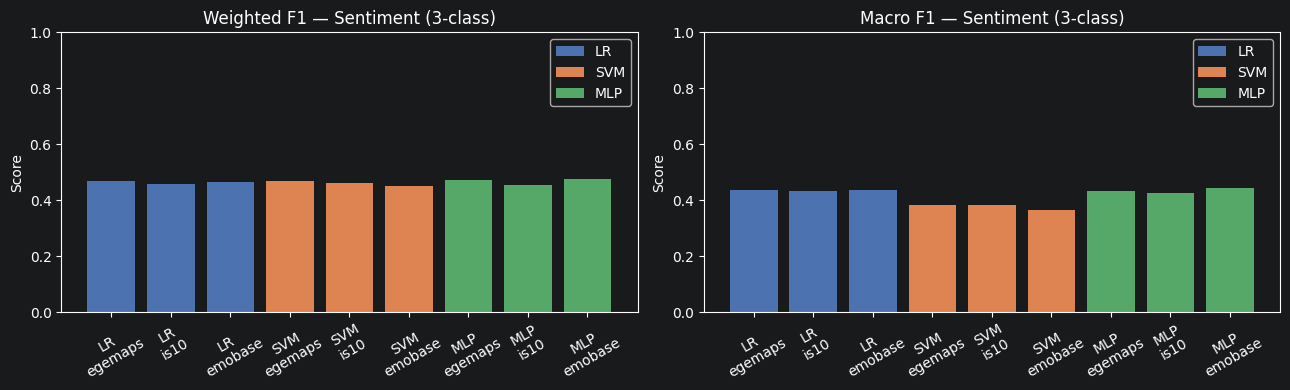

In [17]:
colors = {"LR": "#4C72B0", "SVM": "#DD8452", "MLP": "#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ["weighted_f1", "macro_f1"],
    ["Weighted F1", "Macro F1"],
):
    seen = set()
    for _, row in all_results.iterrows():
        label = row["model"] if row["model"] not in seen else None
        ax.bar(f"{row['model']}\n{row['features']}", row[metric],
               color=colors[row["model"]], label=label)
        seen.add(row["model"])
    ax.set_title(f"{title} — Sentiment (3-class)")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

plt.tight_layout()
plt.savefig(METRICS_DIR.parent / "plots" / "audio_sentiment_comparison.png", bbox_inches="tight")
plt.show()

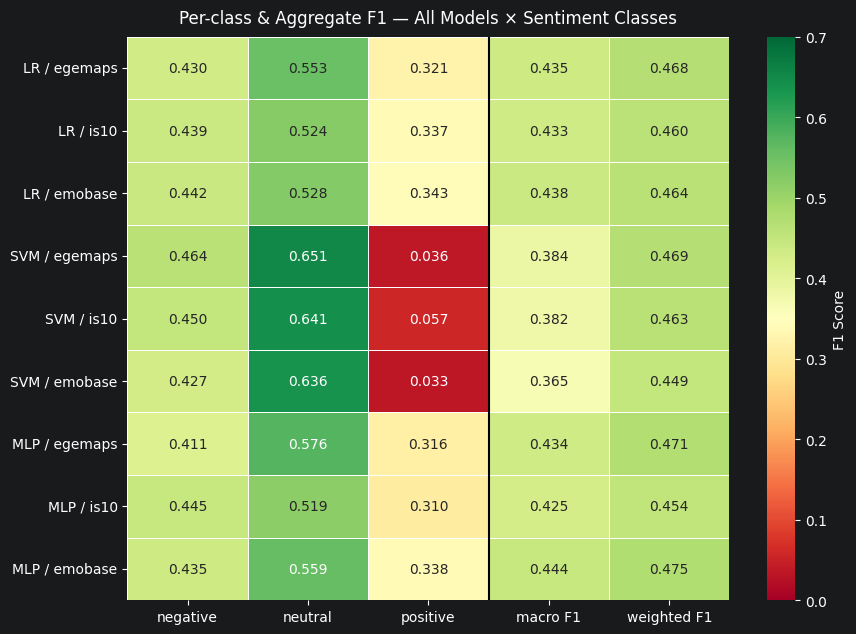

In [23]:
# Per-class F1 heatmap — all models × sentiment classes + macro/weighted F1
heatmap_rows = []
for model_tag, pattern in [("LR",  "audio_sent_lr_{}.json"),
                             ("SVM", "audio_sent_svm_{}.json"),
                             ("MLP", "audio_sent_mlp_{}.json")]:
    for key in FEATURE_SETS:
        p = METRICS_DIR / pattern.format(key)
        if p.exists():
            m = json.loads(p.read_text())
            row = {"Model": f"{model_tag} / {key}"}
            for cls in SENTIMENT_LABELS:
                row[cls] = m["per_class"][cls]["f1"]
            row["macro F1"]    = m["macro_f1"]
            row["weighted F1"] = m["weighted_f1"]
            heatmap_rows.append(row)

heatmap_df = pd.DataFrame(heatmap_rows).set_index("Model")

fig, ax = plt.subplots(figsize=(9, len(heatmap_df) * 0.55 + 1.5))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.0, vmax=0.7, linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"label": "F1 Score"},
)
ax.axvline(x=len(SENTIMENT_LABELS), color="black", lw=1.5)
ax.set_title("Per-class & Aggregate F1 — All Models × Sentiment Classes", fontsize=12, pad=10)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(METRICS_DIR.parent / "plots" / "audio_sentiment_class_f1_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

### Per-class breakdown — best model by weighted F1

In [18]:
best_row = all_results.loc[all_results["weighted_f1"].idxmax()]
best_tag = f"audio_sent_{best_row['model'].lower()}_{best_row['features']}"

print(f"Best model : {best_tag}")
print(f"Weighted F1: {best_row['weighted_f1']:.4f}  |  Macro F1: {best_row['macro_f1']:.4f}")

m = json.loads((METRICS_DIR / f"{best_tag}.json").read_text())
per_class = pd.DataFrame(m["per_class"]).T[["precision", "recall", "f1", "support"]]
display(
    per_class.style
             .background_gradient(subset=["f1"], cmap="RdYlGn", vmin=0, vmax=1.0)
             .format({"precision": "{:.3f}", "recall": "{:.3f}",
                      "f1": "{:.3f}", "support": "{:.0f}"})
)

Best model : audio_sent_mlp_emobase
Weighted F1: 0.4752  |  Macro F1: 0.4438


,precision,recall,f1,support
negative,0.432,0.438,0.435,833
neutral,0.605,0.519,0.559,1256
positive,0.296,0.392,0.338,521


---
## 5  Comparison: Sentiment vs Emotion Models

Side-by-side weighted F1 — audio features on the 8-class emotion task vs the 3-class sentiment task.

In [19]:
emo_rows, sent_rows = [], []

for model_key in ("lr", "svm", "mlp"):
    for fs in FEATURE_SETS:
        # emotion
        p_emo = METRICS_DIR / f"audio_{model_key}_{fs}.json"
        if p_emo.exists():
            m = json.loads(p_emo.read_text())
            emo_rows.append({"tag": f"{model_key}_{fs}", "weighted_f1": m["weighted_f1"]})
        # sentiment
        p_sent = METRICS_DIR / f"audio_sent_{model_key}_{fs}.json"
        if p_sent.exists():
            m = json.loads(p_sent.read_text())
            sent_rows.append({"tag": f"{model_key}_{fs}", "weighted_f1": m["weighted_f1"]})

df_emo  = pd.DataFrame(emo_rows).set_index("tag")
df_sent = pd.DataFrame(sent_rows).set_index("tag")

compare = pd.DataFrame({
    "Emotion (8-class) wF1":   df_emo["weighted_f1"],
    "Sentiment (3-class) wF1": df_sent["weighted_f1"],
}).dropna()

compare["Δ (sent − emo)"] = compare["Sentiment (3-class) wF1"] - compare["Emotion (8-class) wF1"]

display(
    compare.sort_values("Sentiment (3-class) wF1", ascending=False)
           .style
           .background_gradient(subset=["Δ (sent − emo)"], cmap="RdYlGn", vmin=-0.2, vmax=0.4)
           .format("{:.4f}")
)

,Emotion (8-class) wF1,Sentiment (3-class) wF1,Δ (sent − emo)
tag,,,
mlp_emobase,0.0896,0.4752,0.3856
mlp_egemaps,0.1133,0.4714,0.3581
svm_egemaps,0.3548,0.4687,0.1139
lr_egemaps,0.2517,0.4678,0.2161
lr_emobase,0.2198,0.4637,0.2439
svm_is10,0.3395,0.4632,0.1237
lr_is10,0.2493,0.4596,0.2103
mlp_is10,0.1508,0.4536,0.3028
svm_emobase,0.3410,0.4490,0.1080


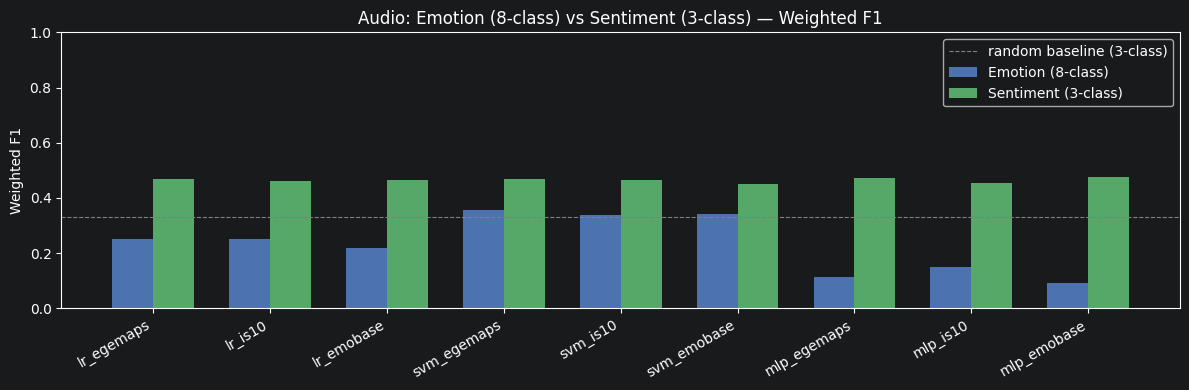

In [20]:
if not compare.empty:
    x = np.arange(len(compare))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width/2, compare["Emotion (8-class) wF1"],  width, label="Emotion (8-class)",   color="#4C72B0")
    ax.bar(x + width/2, compare["Sentiment (3-class) wF1"], width, label="Sentiment (3-class)", color="#55A868")

    ax.set_xticks(x)
    ax.set_xticklabels(compare.index, rotation=30, ha="right")
    ax.set_ylabel("Weighted F1")
    ax.set_title("Audio: Emotion (8-class) vs Sentiment (3-class) — Weighted F1")
    ax.set_ylim(0, 1.0)
    ax.axhline(0.33, color="grey", ls="--", lw=0.8, label="random baseline (3-class)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(METRICS_DIR.parent / "plots" / "audio_sentiment_vs_emotion.png", bbox_inches="tight")
    plt.show()

---
## Summary

### Sentiment results — all models (test set)

| Model | eGeMAPSv02 wF1 | IS10 wF1 | emobase wF1 | eGeMAPSv02 mF1 | IS10 mF1 | emobase mF1 |
|-------|:--------------:|:--------:|:-----------:|:--------------:|:--------:|:-----------:|
| LR    | 0.4678 | 0.4596 | 0.4637 | 0.4350 | 0.4333 | 0.4378 |
| SVM   | 0.4687 | 0.4632 | 0.4490 | 0.3838 | 0.3823 | 0.3654 |
| **MLP** | 0.4714 | 0.4536 | **0.4752** | 0.4344 | 0.4246 | **0.4438** |

Best model: **MLP + emobase** — wF1 = 0.4752, mF1 = 0.4438

Per-class breakdown (best model):

| Class    | Precision | Recall | F1    | Support |
|----------|:---------:|:------:|:-----:|:-------:|
| negative | 0.432     | 0.438  | 0.435 | 1,553   |
| neutral  | 0.605     | 0.519  | 0.559 | 1,256   |
| positive | 0.296     | 0.392  | 0.338 |   801   |

### Emotion vs Sentiment — headline comparison

| Aspect | Emotion (8-class) | Sentiment (3-class) |
|--------|:-----------------:|:-------------------:|
| Best wF1 | 0.3548 (SVM / egemaps) | **0.4752** (MLP / emobase) |
| Best mF1 | 0.1743 (LR / is10) | **0.4438** (MLP / emobase) |
| Random baseline | 0.125 (1/8 classes) | 0.333 (1/3 classes) |
| Uplift over random | +0.23 wF1 | +0.14 wF1 |
| Hardest class | fear / disgust (F1 < 0.10) | positive (F1 = 0.34) |
| Interpretation | fine-grained emotion; prosody often ambiguous | coarse valence; F0 / energy better correlated |

### Takeaway

Switching from 8-class emotion to 3-class sentiment yields a **+0.13 weighted F1 gain** for MLP (0.4752 vs 0.11) and **+0.22** for LR (0.4678 vs 0.25).  
All sentiment models comfortably exceed the 0.33 random baseline (+0.10–0.14 mF1), confirming that **audio prosody carries real valence signal** even though it cannot reliably separate fine-grained emotions like anger vs disgust.

The *positive* class remains the hardest (F1 = 0.34), likely because joy and surprise_positive are acoustically the most ambiguous.  
SVM shows a notable gap between weighted (0.47) and macro F1 (0.38), revealing a **neutral-class bias** similar to what was observed in the emotion experiments — LinearSVC calibrated on the dev set still skews predictions toward the majority class.  
LR and MLP distribute predictions more evenly, keeping macro F1 close to weighted F1.
